<a href="https://colab.research.google.com/github/sk-shahsi/ML_Model/blob/master/Logistic_Regration_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [19]:
df = pd.read_csv('/content/bank-additional-full-1.csv',sep=';')

In [20]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41194,74.0,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41195,74.0,NaN,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41196,74.0,retired,married,NaN,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


age: Age of the customer/client

job: Type of job

married: Marital Status of customer

education: Education level.

default: The person has a history of default credit or loan (Bad credit).

housing: Has housing loan

loan: Has personal loan

contact Contact communication type

month: Last contact month

day_of_week: Last contact day of the week (Mon,Tue..)

duration: Last contact duration in seconds.

campaign: Number of contacts perfomed during this campagin.

pdays: Days since the client was last contacted (999 means never contacted before.)

previous: Number of contacts before this campaign.

poutcome: Outcome of the previous marketing campaign.

emp.var.rate: Employement variation rate (Employement rate)

cons.price.idx: Consumer price index, an indicator that measures average price changes for goods and services bought by households.

cons.conf.idx: Consumer confidence index, it measures how confident/satisfied/optimistic people feel about the economy.

euribor3m: Euribor 3month rate. It is the interest rate at which European banks lend money to each other for 3 months.

nr.employed: Number of employed people.

y: Has the client subscribed/took the fixed deposit/term deposit.

In [21]:
# Because in this problem we need to classify our data into yes or no means
# the person will take the subscription or not
# that why this is binary classification problem
# Thats why we will build a Logistic Regression model

In [22]:
#checking info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41199 entries, 0 to 41198
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41195 non-null  float64
 1   job             41194 non-null  object 
 2   marital         41194 non-null  object 
 3   education       41194 non-null  object 
 4   default         41195 non-null  object 
 5   housing         41196 non-null  object 
 6   loan            41195 non-null  object 
 7   contact         41195 non-null  object 
 8   month           41196 non-null  object 
 9   day_of_week     41196 non-null  object 
 10  duration        41196 non-null  float64
 11  campaign        41196 non-null  float64
 12  pdays           41196 non-null  float64
 13  previous        41196 non-null  float64
 14  poutcome        41194 non-null  object 
 15  emp.var.rate    41196 non-null  float64
 16  cons.price.idx  41195 non-null  float64
 17  cons.conf.idx   41196 non-null 

**Performing EDA**

    # Detecting the null values
    # Detecting the duplicates
    # Detecting the outliers

# Data Preprocessing -> Take action to make the data prepared for model building
    # Handling the null values
    # Handling with the duplicate values
    # handling the ouliers
    # Encoding

In [23]:
for i in df.columns:
  if(df[i].dtype == "object"):
    df[i] = df[i].fillna(df[i].mode()[0])
  else:
      df[i] = df[i].fillna(df[i].mean())

In [24]:
#null check
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [25]:
# Handling the null vaalue


In [26]:
#Handling Dupliacte
df.duplicated().sum()

np.int64(16)

In [27]:
df.drop_duplicates(inplace=True)

In [28]:
df.duplicated().sum()

np.int64(0)

**Dttacted the outliers and handle them---->**

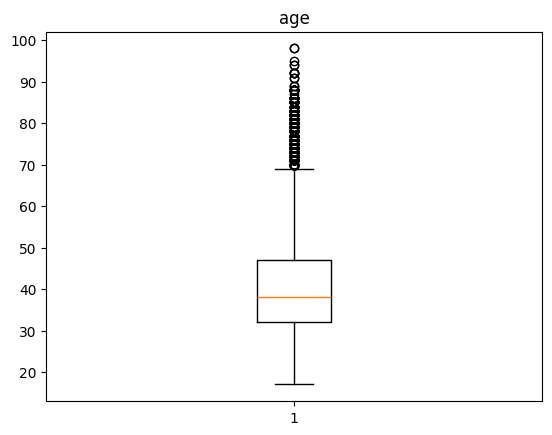

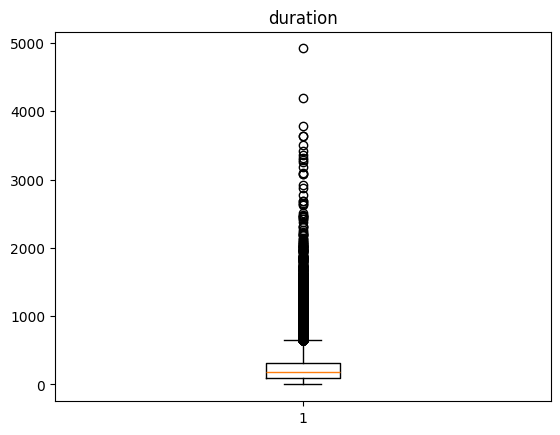

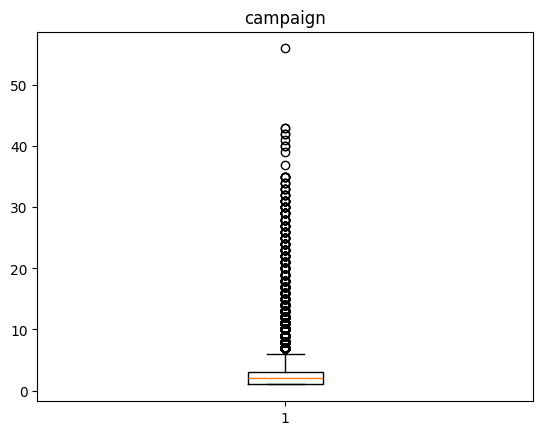

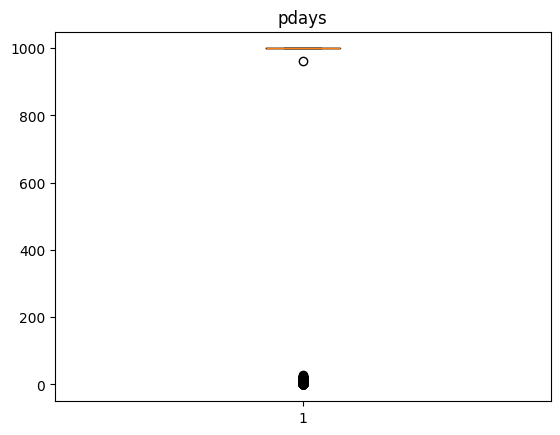

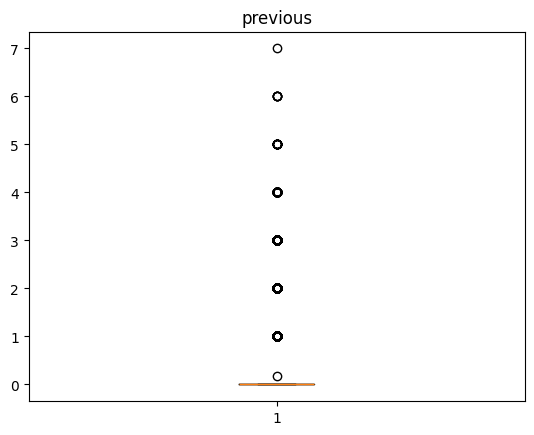

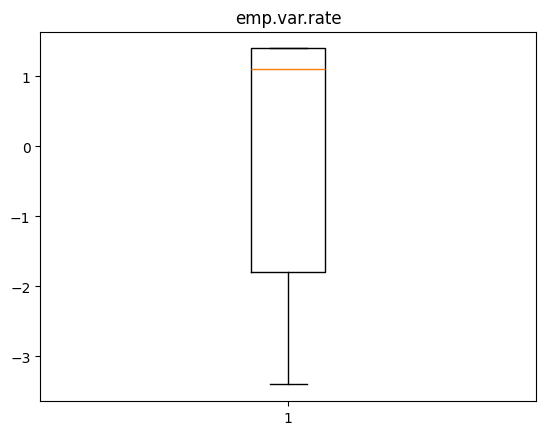

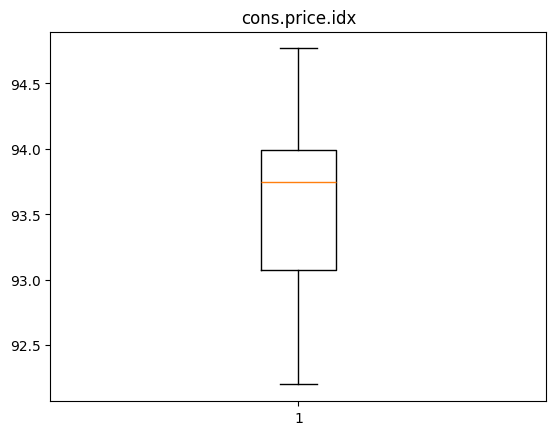

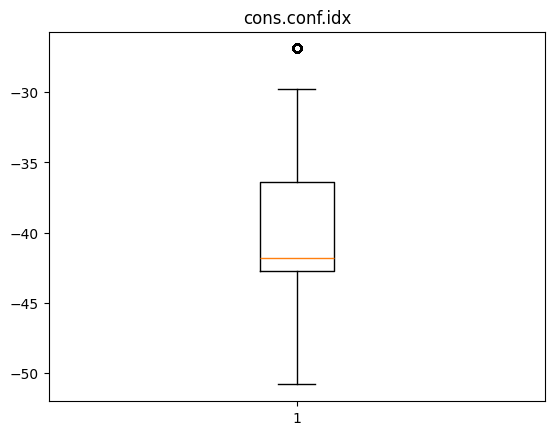

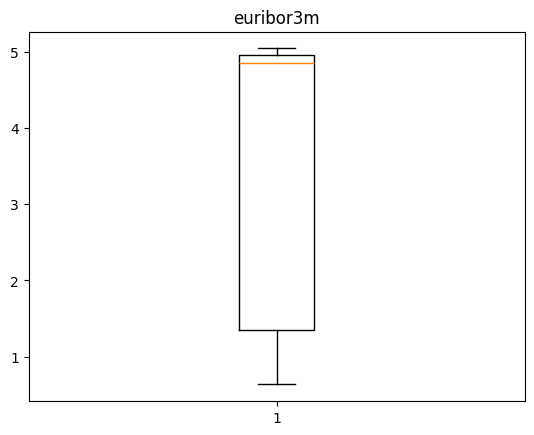

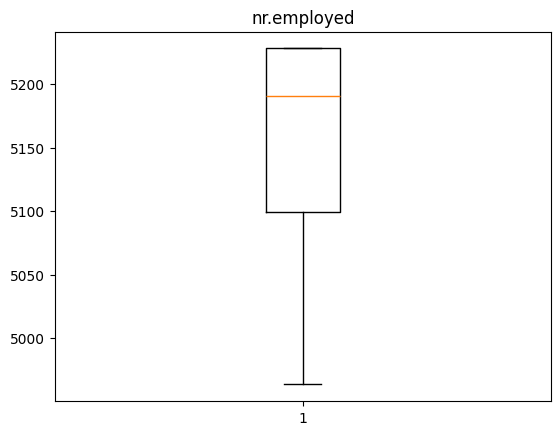

In [29]:
for i in df.columns:
  if(df[i].dtype != "object"):
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()


In [30]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [31]:
outlier = ['duration','campaign','cons.conf.idx']

In [33]:
for i in outlier:
  Q1=df[i].quantile(0.25)
  Q3=df[i].quantile(0.75)
  IQR=Q3-Q1
  ub=Q3+1.5*IQR
  lb = Q1-1.5*IQR
  df = df[(df[i]>=lb) & (df[i]<=ub)]

In [34]:
df.shape

(35547, 21)

In [35]:
#LAble Encoding
from sklearn.preprocessing import LabelEncoder

In [36]:
for i in df.columns:
  if(df[i].dtype =="object"):
    le=LabelEncoder()
    df[i] = le.fit_transform(df[i])


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35547 entries, 0 to 41198
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             35547 non-null  float64
 1   job             35547 non-null  int64  
 2   marital         35547 non-null  int64  
 3   education       35547 non-null  int64  
 4   default         35547 non-null  int64  
 5   housing         35547 non-null  int64  
 6   loan            35547 non-null  int64  
 7   contact         35547 non-null  int64  
 8   month           35547 non-null  int64  
 9   day_of_week     35547 non-null  int64  
 10  duration        35547 non-null  float64
 11  campaign        35547 non-null  float64
 12  pdays           35547 non-null  float64
 13  previous        35547 non-null  float64
 14  poutcome        35547 non-null  int64  
 15  emp.var.rate    35547 non-null  float64
 16  cons.price.idx  35547 non-null  float64
 17  cons.conf.idx   35547 non-null  floa

**Model Bulding**

In [ ]:
# 1. Split the Data (Independent(x) and Dependent(y))
# 2. Train Test Split
# 3. Train the Model
# 4. Test the Model
# 5. Evaluate the Model

In [39]:
# 1. spliting the data(into x and y)
x=df.drop(columns ='y')

In [40]:
y=df['y']

In [43]:
# split the data into traning and testing-->
from sklearn.model_selection import train_test_split


In [44]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=1)

In [45]:
x_train.shape

(28437, 20)

In [46]:
y_train.shape

(28437,)

In [47]:
x_train.shape

(28437, 20)

In [48]:
x_test.shape

(7110, 20)

In [49]:
# Train the model --> Logestic Regression

from sklearn.linear_model import LogisticRegression

In [50]:
model = LogisticRegression()

In [51]:
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [52]:
#Test the model
y_pred = model.predict(x_test)

In [ ]:
#Evalution

In [53]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [54]:
accuracy_score(y_test,y_pred)

0.9313642756680731

In [ ]:
# Second Methods
#Confusion matrix

In [55]:
confusion_matrix(y_test,y_pred)

array([[6418,  124],
       [ 364,  204]])

In [56]:
(6418+204)/(6418+204+364+124)

0.9313642756680731